In [ ]:
#grid_df is the human mobility dataset; traj_df is the Massive step check-ins
#grid_df = pd.read_csv("~/Downloads/humob_datasets/10836269/cell_POIcat.csv.gz")
#poi_map = pd.read_csv("~/Downloads/humob_datasets/10836269/POI_datacategories.csv", header=None)
#poi_cat = pd.read_csv("~/Downloads/Foursquare_mapping.csv")

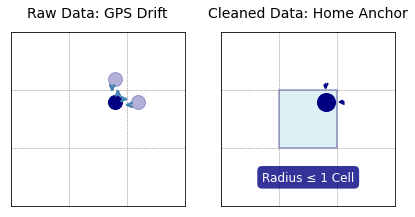

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_grid(ax, title):
    """Helper function to draw a 3x3 grid on a given matplotlib axis."""
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    
    # Draw grid lines
    for i in range(4):
        ax.axhline(i, color='gray', linestyle='--', linewidth=0.5)
        ax.axvline(i, color='gray', linestyle='--', linewidth=0.5)
        
    # Remove axis tick marks for a cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_aspect('equal')

# 1. Set up the figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# --- PLOT 1: RAW DATA (The Ping-Pong Effect) ---
draw_grid(ax1, "Raw Data: GPS Drift")

# Define the coordinates (center of the grid cells)
home_x, home_y = 1.5, 1.5       # The true home (Center)
drift1_x, drift1_y = 2.0, 1.5   # Drift to the right
drift2_x, drift2_y = 1.5, 2.0   # Drift above

# Plot the points (Using Navy Blue)
ax1.plot(home_x, home_y, marker='o', color='navy', markersize=14, label="Recorded Location")
ax1.plot(drift1_x, drift1_y, marker='o', color='navy', markersize=14, alpha=0.3)
ax1.plot(drift2_x, drift2_y, marker='o', color='navy', markersize=14, alpha=0.3)

# Draw arrows bouncing back and forth (Using safer 'arrowstyle' and Steel Blue)
# shrinkA and shrinkB prevent the arrows from overlapping the dots
props = dict(arrowstyle="->", color="steelblue", lw=2.5, shrinkA=10, shrinkB=10)

# Drift to the right and back
ax1.annotate("", xy=(drift1_x, drift1_y+0.05), xytext=(home_x, home_y+0.05), arrowprops=props)
ax1.annotate("", xy=(home_x, home_y-0.05), xytext=(drift1_x, drift1_y-0.05), arrowprops=props)

# Drift upwards and back
ax1.annotate("", xy=(drift2_x+0.05, drift2_y), xytext=(home_x+0.05, home_y), arrowprops=props)
ax1.annotate("", xy=(home_x-0.05, home_y), xytext=(drift2_x-0.05, drift2_y), arrowprops=props)


# --- PLOT 2: CLEANED DATA (The Home Anchor) ---
draw_grid(ax2, "Cleaned Data: Home Anchor")

# Highlight the anchor cell with a subtle light blue background
anchor_cell = patches.Rectangle((1, 1), 1, 1, linewidth=1.5, edgecolor='navy', facecolor='lightblue', alpha=0.4)
ax2.add_patch(anchor_cell)

# Plot the single anchored point
ax2.plot(home_x, home_y, marker='o', color='navy', markersize=18, label="Anchor Location")

# Draw dashed arrows pulling the drift back into the center
pull_props = dict(arrowstyle="->", color="navy", lw=2, ls="--", shrinkA=5, shrinkB=12)
ax2.annotate("", xy=(home_x, home_y), xytext=(drift1_x, drift1_y), arrowprops=pull_props)
ax2.annotate("", xy=(home_x, home_y), xytext=(drift2_x, drift2_y), arrowprops=pull_props)

# Add text to explain the radius
ax2.text(1.5, 0.5, "Radius ≤ 1 Cell", ha='center', va='center', fontsize=12, color='white', 
         bbox=dict(facecolor='navy', edgecolor='none', alpha=0.8, boxstyle="round,pad=0.4"))

# Adjust layout and show
plt.tight_layout()
plt.show()

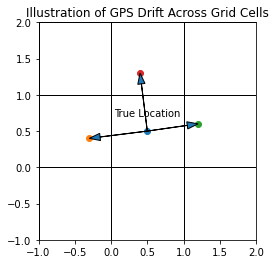

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Draw grid (3x3)
for x in range(-1, 2):
    for y in range(-1, 2):
        rect = plt.Rectangle((x, y), 1, 1, fill=False)
        ax.add_patch(rect)

# True location (center cell)
ax.scatter(0.5, 0.5)
ax.text(0.5, 0.7, "True Location", ha='center')

# Drift points in neighboring cells
drift_points = [(-0.3, 0.4), (1.2, 0.6), (0.4, 1.3)]
for x, y in drift_points:
    ax.scatter(x, y)

# Arrows showing drift
for x, y in drift_points:
    ax.arrow(0.5, 0.5, x-0.5, y-0.5, head_width=0.1, length_includes_head=True)

ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2)
ax.set_aspect('equal')

plt.title("Illustration of GPS Drift Across Grid Cells")
plt.show()

In [1]:
import pandas as pd
df = pd.read_parquet("~/Downloads/enriched_human_mobility_100k_v3.parquet")
##df2 = pd.read_parquet("~/Downloads/function_enriched_human_mobility_100k_v1.parquet")
##df3 = pd.read_parquet("~/Downloads/function_enriched_human_mobility_100k_v2.parquet")

🧠 1. Check POI topic distribution (LDA features)
❓ What this tells you
 - Are topics meaningful?
 - Are they skewed or balanced?
 - Do locations have distinct functional signatures?

📊 Plot: Topic distribution

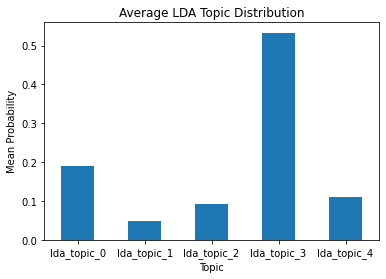

In [17]:
import matplotlib.pyplot as plt

# assume lda_cols = ['topic_0', ..., 'topic_6']
lda_cols = [col for col in df.columns if 'topic_' in col]

topic_means = df[lda_cols].mean()

plt.figure()
topic_means.plot(kind='bar')
plt.title("Average LDA Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Mean Probability")
plt.xticks(rotation=0)
plt.show()

📊 Plot: Topic distribution per location (spatial heatmap)

AttributeError: 'numpy.ndarray' object has no attribute 'spines'

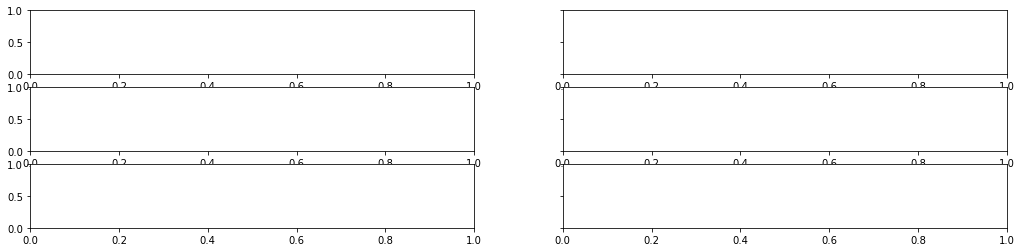

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Topic names for interpretation
topic_names = ['Residential/Leisure', 'Parks/Recreation', 'Transport', 'Business', 'Civic']

# Create 1x5 subplot
fig, axs = plt.subplots(5, 1, figsize=(20, 4), sharey=True)

# Loop through topics
for i, topic_name in enumerate(topic_names):
    topic_col = f'lda_topic_{i}'  # matches your DataFrame column
    # Pivot table to prepare for heatmap
    pivot = df.pivot_table(index='y', columns='x', values=topic_col, aggfunc='mean')
    
    # Draw heatmap on the correct axis
    sns.heatmap(pivot, ax=axs[i], cmap='viridis', cbar=i==4)  # show colorbar only on last plot
    axs[i].set_title(topic_name)
    axs[i].set_xlabel('X')
    if i == 0:
        axs[i].set_ylabel('Y')

plt.suptitle('Spatial Distribution of LDA-Derived Functional Topics')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Topic names for interpretation
topic_names = ['Residential/Leisure', 'Parks/Recreation', 'Transport', 'Business', 'Civic']

# Create 1x5 subplot
fig, axs = plt.subplots(5, 1, figsize=(20, 4), sharey=True)

# Loop through topics
for i, topic_name in enumerate(topic_names):
    topic_col = f'lda_topic_{i}'  # matches your DataFrame column
    # Pivot table to prepare for heatmap
    pivot = df.pivot_table(index='y', columns='x', values=topic_col, aggfunc='mean')
    
    # Draw heatmap on the correct axis
    sns.heatmap(pivot, ax=axs[i], cmap='viridis', cbar=i==4)  # show colorbar only on last plot
    axs[i].set_title(topic_name)
    axs[i].set_xlabel('X')
    if i == 0:
        axs[i].set_ylabel('Y')

plt.suptitle('Spatial Distribution of LDA-Derived Functional Topics')
plt.tight_layout()
plt.show()

🧠 2. POI density distribution
❓ What this tells you
Is it skewed? (very likely)
Do you need log scaling?

📊 Plot: Histogram

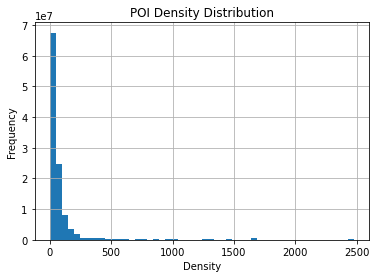

In [8]:
plt.figure()
df['poi_density'].hist(bins=50)
plt.title("POI Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

📊 Better: Log-scale version

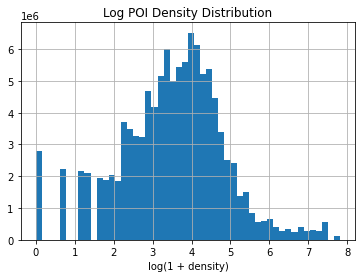

In [9]:
import numpy as np

plt.figure()
np.log1p(df['poi_density']).hist(bins=50)
plt.title("Log POI Density Distribution")
plt.xlabel("log(1 + density)")
plt.show()

🧠 3. Weekend vs weekday behavior
❓ What this tells you
Does movement differ on weekends?

📊 Plot: Density / activity comparison

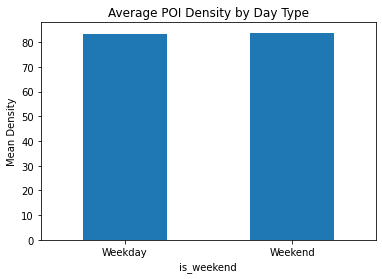

In [10]:
df['is_weekend'] = df['d'].isin([5,6]).astype(int)  # adjust if needed

weekend_density = df.groupby('is_weekend')['poi_density'].mean()

plt.figure()
weekend_density.plot(kind='bar')
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.title("Average POI Density by Day Type")
plt.ylabel("Mean Density")
plt.show()

📊 Plot: Temporal activity

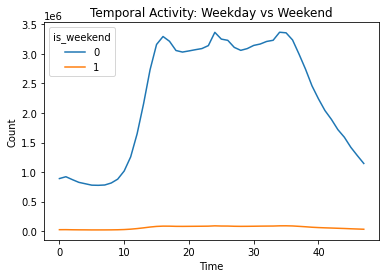

In [11]:
hourly = df.groupby(['t', 'is_weekend']).size().unstack()

hourly.plot()
plt.title("Temporal Activity: Weekday vs Weekend")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()

🧠 4. Person type behavior differences
❓ What this tells you
Do different users behave differently?

📊 Plot: POI density by person type

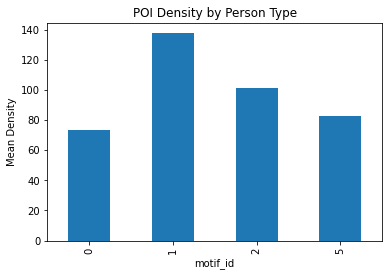

In [17]:
plt.figure()
df.groupby('motif_id')['poi_density'].mean().plot(kind='bar')
plt.title("POI Density by Person Type")
plt.ylabel("Mean Density")
plt.show()

In [6]:
type_cols = ['motif_0', 'motif_1', 'motif_2', 'motif_3', 'motif_4', 'motif_5']

# ['uid'] + type_cols creates a single list: ['uid', 'motif_0', 'motif_1'...]
df_users = df[['uid'] + type_cols].groupby('uid').mean()

In [ ]:
import matplotlib.pyplot as plt

type_cols = ['motif_0', 'motif_1', 'motif_2', 'motif_3', 'motif_4', 'motif_5']

type_names = ['Commuter', 'Single Tour', 'Multi Tour', 'Multi Tour II', 'Stay Home', 'Other']

# Sort users for better visual clarity (optional)
df_sorted = df_users.sort_values(by=type_cols, ascending=False)

# Prepare stacked bar chart
bottom = [0] * len(df_sorted)

plt.figure(figsize=(10, 6))

for i, col in enumerate(type_cols):
    plt.bar(df_sorted.index, df_sorted[col], bottom=bottom, label=type_names[i])
    bottom = [bottom[j] + df_sorted[col].iloc[j] for j in range(len(bottom))]

plt.xlabel("Users")
plt.ylabel("Proportion of Days")
plt.title("Distribution of Person Types Across Users (60-Day Window)")
plt.legend()
plt.tight_layout()
plt.show()

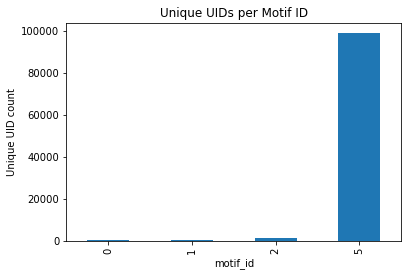

In [20]:
plt.figure()
df.groupby('motif_id')['uid'].nunique().plot(kind='bar')
plt.title("Unique UIDs per Motif ID")
plt.ylabel("Unique UID count")
plt.show()

📊 Plot: Topic preference by person type

In [ ]:
topic_by_person = df.groupby('person_type')[lda_cols].mean()

topic_by_person.T.plot()
plt.title("Topic Preferences by Person Type")
plt.xlabel("Topic")
plt.ylabel("Mean Value")
plt.show()

🧠 5. Spatial trajectory density (VERY strong for thesis)
This is one of the most convincing visuals.

📊 Plot: Movement heatmap

In [ ]:
pivot = df.pivot_table(index='y', columns='x', values='uid', aggfunc='count')

plt.figure()
sns.heatmap(pivot)
plt.title("Trajectory Density Map")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
🧠 6. Correlation between features (IMPORTANT)
❓ What this tells you
Are features redundant?

In [ ]:
features = lda_cols + ['poi_density']

corr = df[features].corr()

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
🧠 7. Feature importance proxy (very useful)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df[lda_cols + ['poi_density']]
y = df['person_type']  # or next location, etc.

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().plot(kind='barh')
plt.title("Feature Importance (Proxy Model)")
plt.show()